In [1]:
# ruff: noqa  # Expect this notebook to be of bad quality
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from misophonia_anc._mlflow_stats import get_mlflow_metric_history, auto_combine_mean_with_std, get_pretty_name

/build/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
get_mlflow_metric_history(("model-baseline-rep1", "model-baseline-rep2"), "train/epoch/loss")

,run_name,step,timestamp,train/epoch/loss
0,model-baseline-rep1,1,1777840596508,-7.233837
1,model-baseline-rep1,2,1777841952199,-8.367071
2,model-baseline-rep1,3,1777843307621,-8.694747
3,model-baseline-rep1,4,1777844657384,-8.890339
4,model-baseline-rep1,5,1777846007626,-9.033155
...,...,...,...,...
155,model-baseline-rep2,76,1777774004287,-12.344591
156,model-baseline-rep2,77,1777775557581,-12.330220
157,model-baseline-rep2,78,1777777106462,-12.402681
158,model-baseline-rep2,79,1777778657748,-12.346035


In [4]:
auto_combine_mean_with_std(
    ("model-baseline-rep1", "model-baseline-rep2", "model-baseline-rep3"), "val/epoch/si_snr_improvement"
)

,run_name,step,timestamp,val/epoch/si_snr_improvement,val/epoch/si_snr_improvement_std
0,model-baseline-rep1,1,1777840596508,0.683738,1.308915
1,model-baseline-rep1,1,1777840596508,0.683738,1.548759
2,model-baseline-rep1,1,1777840596508,0.683738,1.317182
3,model-baseline-rep1,2,1777841952199,1.134515,1.681772
4,model-baseline-rep1,2,1777841952199,1.134515,1.648133
...,...,...,...,...,...
715,model-baseline-rep3,79,1777882691665,2.283842,5.121564
716,model-baseline-rep3,79,1777882691665,2.283842,4.886770
717,model-baseline-rep3,80,1777884041271,1.669377,5.009050
718,model-baseline-rep3,80,1777884041271,1.669377,4.734550


In [5]:
def plot_loss(
    losses: pd.DataFrame,
    mean_col: str,
    *,
    std_label: str = "Std Dev",
    std_col: str | None = None,
) -> None:
    sns.set_style("whitegrid")
    plt.figure(figsize=(10, 6))

    for run_name, group in losses.groupby("run_name"):
        pretty_run_name = get_pretty_name(run_name)
        sns.lineplot(data=group, x="step", y=mean_col, label=f"{pretty_run_name} (mean)")

        if std_col is not None:
            plt.fill_between(
                group["step"],
                group[mean_col] - group[std_col],
                group[mean_col] + group[std_col],
                alpha=0.3,
                label=f"{std_label} ({run_name})",
            )

    plt.title("Validation SI-SNR Improvement Over Steps")
    plt.xlabel("Step")
    plt.ylabel("SI-SNR Improvement (dB)")
    plt.legend()
    plt.show()

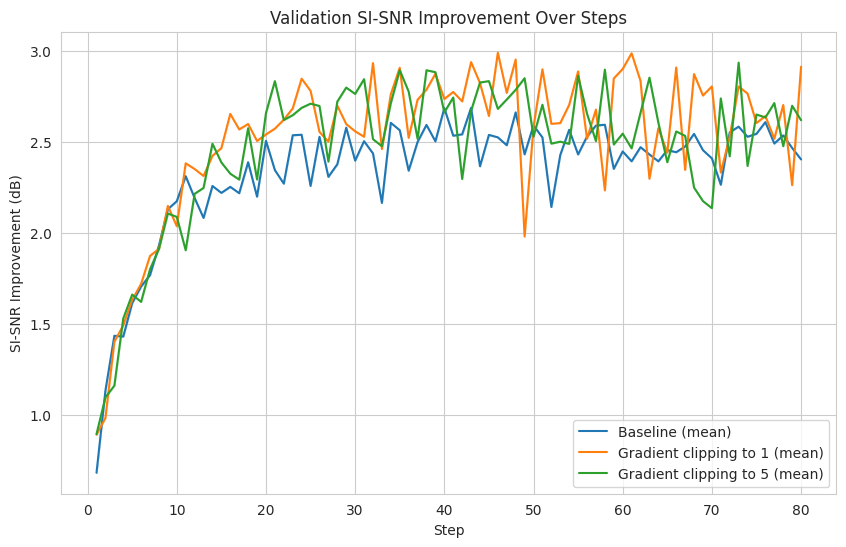

In [6]:
plot_loss(
    auto_combine_mean_with_std(
        (
            "model-baseline-rep1",
            "model-gradclip-1",
            "model-gradclip-5",
        ),
        "val/epoch/si_snr_improvement",
    ),
    "val/epoch/si_snr_improvement",
    # std_col="val/epoch/si_snr_improvement_std",
)

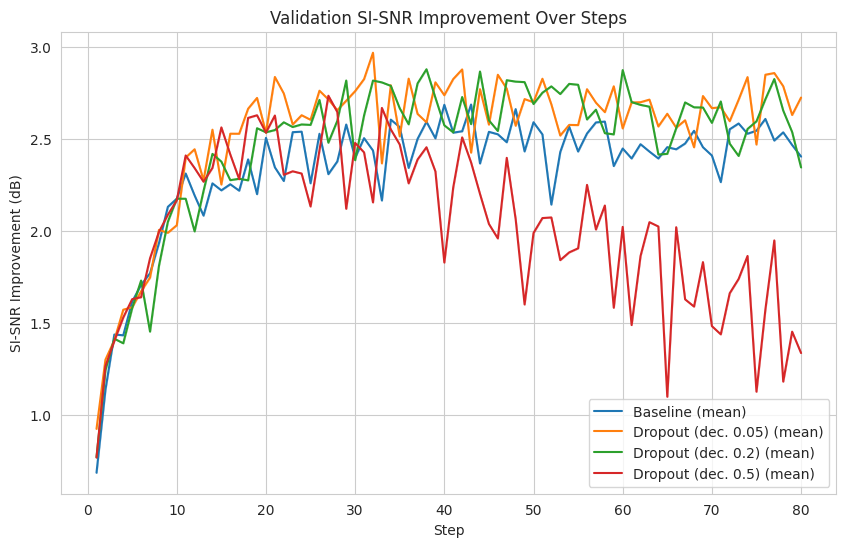

In [7]:
plot_loss(
    auto_combine_mean_with_std(
        (
            "model-dropout-dec-0.05",
            "model-baseline-rep1",
            "model-dropout-dec-0.2",
            "model-dropout-dec-0.5",
        ),
        "val/epoch/si_snr_improvement",
    ),
    "val/epoch/si_snr_improvement",
    # std_col="val/epoch/si_snr_improvement_std",
)

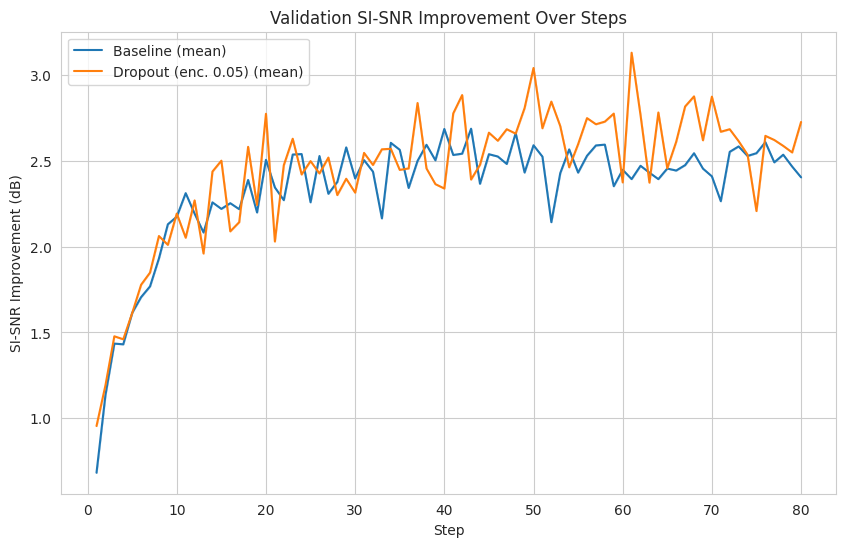

In [8]:
plot_loss(
    auto_combine_mean_with_std(
        (
            "model-baseline-rep1",
            "model-dropout-enc-0.05",
        ),
        "val/epoch/si_snr_improvement",
    ),
    "val/epoch/si_snr_improvement",
    # std_col="val/epoch/si_snr_improvement_std",
)

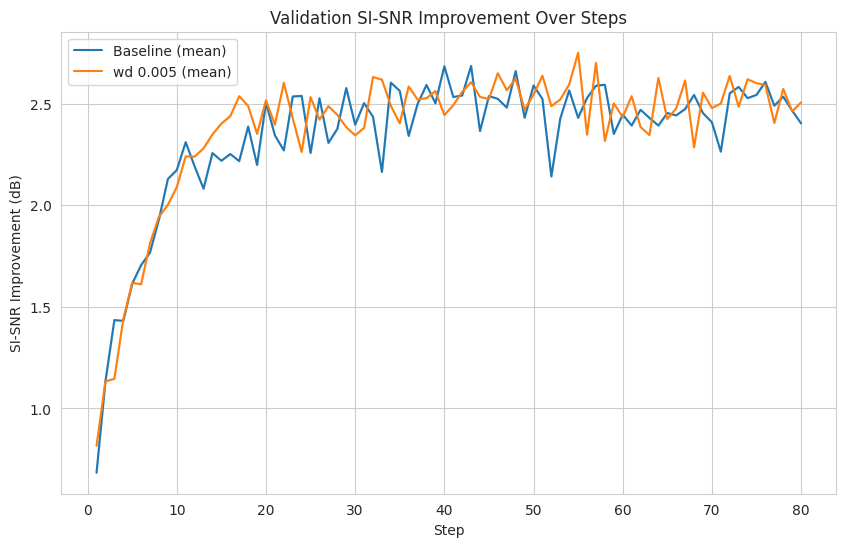

In [9]:
plot_loss(
    auto_combine_mean_with_std(
        (
            "model-baseline-rep1",
            "model-lr-0.0005-wd-0.005",
        ),
        "val/epoch/si_snr_improvement",
    ),
    "val/epoch/si_snr_improvement",
    # std_col="val/epoch/si_snr_improvement_std",
)